# 03 — Forecasting ML (Daily)

Forecast **daily GMV** from delivered orders, then roll up to monthly totals for reporting.

## Pipeline
1. Query `gold_fact_orders` by `order_date` → `daily_business_metrics.csv`
2. Build lag / rolling features (`shift(1)` before rolling to avoid leakage)
3. **Fast tuning + backtest**: `TimeSeriesSplit` on the training set (no shuffle); test set = last 3 calendar months
4. Recursively forecast the next 30 days; export daily + monthly summaries

## Outputs
- `data/processed/daily_business_metrics.csv`
- `data/output/forecast_result_daily.csv`
- `data/output/forecast_result_monthly.csv`
- `data/output/rf_model_performance.csv`
- `data/output/rf_feature_importance.csv`

## Metrics (holdout test set)
| Role | Grain | Metrics |
|------|-------|---------|
| **Primary tuning** | Daily | RMSE (`GridSearchCV` scoring) |
| Secondary check | Daily | MAE, MAPE, R² |
| Business evaluation | Monthly (sum of daily preds) | MAE, MAPE |

In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys
import getpass
import uuid
from datetime import datetime, timezone
from urllib.parse import quote_plus


def ensure_pkg(module_name: str, pip_name: str) -> None:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])


ensure_pkg("sklearn", "scikit-learn")
ensure_pkg("sqlalchemy", "sqlalchemy")
ensure_pkg("psycopg2", "psycopg2-binary")
ensure_pkg("matplotlib", "matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

ROOT = Path("..").resolve()
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "data" / "output"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "daily_business_metrics.csv"
FORECAST_DAILY_PATH = OUTPUT_DIR / "forecast_result_daily.csv"
FORECAST_MONTHLY_PATH = OUTPUT_DIR / "forecast_result_monthly.csv"
PERFORMANCE_PATH = OUTPUT_DIR / "rf_model_performance.csv"
FEATURE_IMPORTANCE_PATH = OUTPUT_DIR / "rf_feature_importance.csv"

FORECAST_DAYS = 30
TEST_MONTHS = 3  # hold out the last N calendar months for backtest

DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB", "ecommerce")
DB_USER = os.getenv("POSTGRES_USER") or getpass.getuser()
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD", "")

password_part = quote_plus(DB_PASSWORD)
conn_str = f"postgresql+psycopg2://{DB_USER}:{password_part}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)


def q(sql: str) -> pd.DataFrame:
    return pd.read_sql(text(sql), engine)


try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print(f"Connected: {DB_HOST}:{DB_PORT}/{DB_NAME} as {DB_USER}")
except Exception as e:
    raise RuntimeError(
        "Database connection failed. Set env vars before running:\n"
        "POSTGRES_HOST, POSTGRES_PORT, POSTGRES_DB, POSTGRES_USER, POSTGRES_PASSWORD\n"
        f"Current tried user={DB_USER}, db={DB_NAME}, host={DB_HOST}:{DB_PORT}.\n"
        f"Original error: {e}"
    ) from e

print(f"Metrics CSV: {INPUT_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Connected: localhost:5432/ecommerce as sherrywang
Metrics CSV: /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/processed/daily_business_metrics.csv
Output dir: /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/output


## 1) Export Daily Business Metrics

Delivered orders only; one row per `order_date` (GMV / orders / unique customers).

In [2]:
DAILY_METRICS_SQL = """
SELECT
    order_purchase_date AS order_date,
    COUNT(DISTINCT order_id) AS orders,
    SUM(order_gmv) AS gmv,
    COUNT(DISTINCT customer_unique_id) AS unique_customers
FROM public.gold_fact_orders
WHERE order_status = 'delivered'
  AND order_purchase_date IS NOT NULL
GROUP BY 1
ORDER BY 1
"""

metrics_df = q(DAILY_METRICS_SQL)
metrics_df.to_csv(INPUT_PATH, index=False)
print(f"Wrote {INPUT_PATH} ({len(metrics_df)} days with orders)")

metrics_df.head()

Wrote /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/processed/daily_business_metrics.csv (612 days with orders)


,order_date,orders,gmv,unique_customers
0,2016-09-15,1,143.46,1
1,2016-10-03,7,559.53,7
2,2016-10-04,54,9821.42,54
3,2016-10-05,35,7209.50,35
4,2016-10-06,41,6798.90,41


## 2) Load and Prepare Daily Time Series

Fill a continuous daily calendar (zero GMV on days with no delivered orders) so lags are well-defined.

In [3]:
df = metrics_df.copy()
df["order_date"] = pd.to_datetime(df["order_date"])
df = df.sort_values("order_date").reset_index(drop=True)

day_spine = pd.DataFrame({
    "order_date": pd.date_range(df["order_date"].min(), df["order_date"].max(), freq="D")
})
df = day_spine.merge(df, on="order_date", how="left")
df[["orders", "gmv", "unique_customers"]] = df[["orders", "gmv", "unique_customers"]].fillna(0)

print(f"Daily spine: {len(df)} rows ({df['order_date'].min().date()} → {df['order_date'].max().date()})")
df.tail()

Daily spine: 714 rows (2016-09-15 → 2018-08-29)


,order_date,orders,gmv,unique_customers
709,2018-08-25,69.0,11737.76,69.0
710,2018-08-26,73.0,9333.16,73.0
711,2018-08-27,66.0,6111.61,66.0
712,2018-08-28,39.0,4121.22,39.0
713,2018-08-29,11.0,1762.70,11.0


## 3) Feature Engineering

Predict daily `gmv`. Rolling stats use `shift(1)` first so the current day target is not in the window.

In [4]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    out["trend"] = np.arange(len(out))
    out["day_of_week"] = out["order_date"].dt.dayofweek
    out["month"] = out["order_date"].dt.month
    out["quarter"] = out["order_date"].dt.quarter
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)

    for lag in (1, 2, 3, 6, 7):
        out[f"gmv_lag_{lag}"] = out["gmv"].shift(lag)

    # Past-only series for rolling (no same-day gmv in the window).
    gmv_past = out["gmv"].shift(1)
    out["gmv_rolling_mean_3"] = gmv_past.rolling(3).mean()
    out["gmv_rolling_mean_6"] = gmv_past.rolling(6).mean()
    out["gmv_rolling_mean_7"] = gmv_past.rolling(7).mean()
    out["gmv_rolling_mean_28"] = gmv_past.rolling(28).mean()
    out["gmv_rolling_std_3"] = gmv_past.rolling(3).std()

    out["orders_lag_1"] = out["orders"].shift(1)
    out["orders_lag_7"] = out["orders"].shift(7)
    out["customers_lag_1"] = out["unique_customers"].shift(1)
    out["customers_lag_7"] = out["unique_customers"].shift(7)

    return out


feature_df = add_features(df)
feature_cols = [
    "trend",
    "day_of_week",
    "month",
    "quarter",
    "month_sin",
    "month_cos",
    "gmv_lag_1",
    "gmv_lag_2",
    "gmv_lag_3",
    "gmv_lag_6",
    "gmv_lag_7",
    "gmv_rolling_mean_3",
    "gmv_rolling_mean_6",
    "gmv_rolling_mean_7",
    "gmv_rolling_mean_28",
    "gmv_rolling_std_3",
    "orders_lag_1",
    "orders_lag_7",
    "customers_lag_1",
    "customers_lag_7",
]

dataset = feature_df.dropna(subset=feature_cols + ["gmv"]).reset_index(drop=True)
print(f"Training-ready rows: {len(dataset)} (daily samples)")
dataset[["order_date", "gmv"] + feature_cols[:6]].head()

Training-ready rows: 686 (daily samples)


,order_date,gmv,trend,day_of_week,month,quarter,month_sin,month_cos
0,2016-10-13,0.0,28,3,10,4,-0.866025,0.5
1,2016-10-14,0.0,29,4,10,4,-0.866025,0.5
2,2016-10-15,0.0,30,5,10,4,-0.866025,0.5
3,2016-10-16,0.0,31,6,10,4,-0.866025,0.5
4,2016-10-17,0.0,32,0,10,4,-0.866025,0.5


## Helper functions

`tune_and_evaluate_rf` — TimeSeriesSplit tuning + last-N-month holdout backtest.

`recursive_forecast` — multi-step daily GMV forecast using predicted lags after day 1.

In [5]:
DEFAULT_PARAM_GRID = {
    "n_estimators": [200, 300, 500],
    "max_depth": [6, 8, 10],
    "min_samples_leaf": [2, 3, 5],
}


def split_train_test_last_months(
    dataset: pd.DataFrame,
    test_months: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Timestamp]:
    """Hold out the last `test_months` calendar months (time-ordered, no shuffle)."""
    last_month = dataset["order_date"].max().to_period("M")
    test_start = (last_month - (test_months - 1)).to_timestamp()
    train = dataset[dataset["order_date"] < test_start].copy()
    test = dataset[dataset["order_date"] >= test_start].copy()
    if len(train) == 0 or len(test) == 0:
        raise ValueError(
            f"Invalid train/test split: train={len(train)}, test={len(test)}. "
            f"Check test_months={test_months}."
        )
    return train, test, test_start


def build_performance_table(
    tune_search: GridSearchCV,
    *,
    forecast_run_id: str,
    test_months: int,
    cv_splits: int,
    train: pd.DataFrame,
    test: pd.DataFrame,
    monthly_eval: pd.DataFrame,
    daily_rmse: float,
    daily_mae: float,
    daily_mape: float,
    daily_r2: float,
    monthly_mae: float,
    monthly_mape: float,
) -> pd.DataFrame:
    run_meta = {
        "forecast_run_id": forecast_run_id,
        "model": "RandomForestRegressor",
        "best_params": str(tune_search.best_params_),
        "test_split": f"last_{test_months}_calendar_months",
        "cv_method": "TimeSeriesSplit",
        "cv_splits": cv_splits,
        "cv_best_daily_rmse": -tune_search.best_score_,
        "train_start": train["order_date"].min().date(),
        "train_end": train["order_date"].max().date(),
        "test_start": test["order_date"].min().date(),
        "test_end": test["order_date"].max().date(),
        "train_rows": len(train),
        "test_rows": len(test),
        "monthly_test_rows": len(monthly_eval),
    }
    return pd.DataFrame([
        {**run_meta, "metric_role": "primary_tuning", "grain": "daily", "metric": "rmse", "value": daily_rmse},
        {**run_meta, "metric_role": "secondary_check", "grain": "daily", "metric": "mae", "value": daily_mae},
        {**run_meta, "metric_role": "secondary_check", "grain": "daily", "metric": "mape", "value": daily_mape},
        {**run_meta, "metric_role": "secondary_check", "grain": "daily", "metric": "r2", "value": daily_r2},
        {**run_meta, "metric_role": "business_eval", "grain": "monthly", "metric": "mae", "value": monthly_mae},
        {**run_meta, "metric_role": "business_eval", "grain": "monthly", "metric": "mape", "value": monthly_mape},
    ])


def build_feature_importance_table(
    model,
    feature_cols: list[str],
    *,
    forecast_run_id: str,
    generated_at: datetime | str,
    model_name: str = "RandomForestRegressor",
) -> pd.DataFrame:
    """One row per model version x feature."""
    generated_at_str = pd.Timestamp(generated_at).isoformat()
    importance_df = (
        pd.DataFrame({
            "forecast_run_id": forecast_run_id,
            "generated_at": generated_at_str,
            "model": model_name,
            "feature": feature_cols,
            "importance": model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance_df.insert(3, "rank", np.arange(1, len(importance_df) + 1))
    return importance_df[
        ["forecast_run_id", "generated_at", "model", "rank", "feature", "importance"]
    ]


def tune_and_evaluate_rf(
    dataset: pd.DataFrame,
    feature_cols: list[str],
    *,
    test_months: int = 3,
    param_grid: dict | None = None,
    random_state: int = 42,
    forecast_run_id: str | None = None,
) -> dict:
    """Tune RF on train with TimeSeriesSplit; evaluate on last-N-month holdout."""
    forecast_run_id = forecast_run_id or uuid.uuid4().hex
    generated_at = datetime.now(timezone.utc)
    generated_at_str = pd.Timestamp(generated_at).isoformat()
    train, test, test_start = split_train_test_last_months(dataset, test_months)
    print(
        f"Backtest split | train: {train['order_date'].min().date()} → {train['order_date'].max().date()} "
        f"({len(train)} days) | test: {test['order_date'].min().date()} → {test['order_date'].max().date()} "
        f"({len(test)} days, last {test_months} months)"
    )

    X_train, y_train = train[feature_cols], train["gmv"]
    X_test, y_test = test[feature_cols], test["gmv"]

    param_grid = param_grid or DEFAULT_PARAM_GRID
    cv_splits = min(5, max(2, len(train) // 60))
    tscv = TimeSeriesSplit(n_splits=cv_splits)

    tune_search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=random_state, n_jobs=-1),
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
        refit=True,
    )
    tune_search.fit(X_train, y_train)
    rf_model = tune_search.best_estimator_
    test_pred = rf_model.predict(X_test)

    daily_rmse = mean_squared_error(y_test, test_pred) ** 0.5
    daily_mae = mean_absolute_error(y_test, test_pred)
    daily_mape = mean_absolute_percentage_error(y_test, test_pred)
    daily_r2 = r2_score(y_test, test_pred)

    test_eval = test[["order_date", "gmv"]].copy()
    test_eval["predicted_gmv"] = test_pred
    monthly_eval = (
        test_eval.assign(month_start=test_eval["order_date"].dt.to_period("M").dt.to_timestamp())
        .groupby("month_start", as_index=False)[["gmv", "predicted_gmv"]]
        .sum()
    )
    monthly_mae = mean_absolute_error(monthly_eval["gmv"], monthly_eval["predicted_gmv"])
    monthly_mape = mean_absolute_percentage_error(monthly_eval["gmv"], monthly_eval["predicted_gmv"])

    performance = build_performance_table(
        tune_search,
        forecast_run_id=forecast_run_id,
        test_months=test_months,
        cv_splits=cv_splits,
        train=train,
        test=test,
        monthly_eval=monthly_eval,
        daily_rmse=daily_rmse,
        daily_mae=daily_mae,
        daily_mape=daily_mape,
        daily_r2=daily_r2,
        monthly_mae=monthly_mae,
        monthly_mape=monthly_mape,
    )
    metrics_pivot = performance.pivot_table(
        index="metric_role",
        columns=["grain", "metric"],
        values="value",
        aggfunc="first",
    )

    return {
        "forecast_run_id": forecast_run_id,
        "generated_at": generated_at_str,
        "rf_model": rf_model,
        "tune_search": tune_search,
        "train": train,
        "test": test,
        "test_start": test_start,
        "test_eval": test_eval,
        "monthly_eval": monthly_eval,
        "performance": performance,
        "metrics_pivot": metrics_pivot,
        "cv_splits": cv_splits,
    }


def _estimate_forecast_assumptions(history: pd.DataFrame, window: int = 90) -> tuple[float, float]:
    """Use recent actuals to keep forecasted orders/customers consistent with forecasted GMV."""
    recent = history[(history["orders"] > 0) & (history["gmv"] > 0)].tail(window)
    if recent.empty:
        raise ValueError("Cannot estimate forecast assumptions: no recent days with positive orders and GMV.")

    recent_aov = recent["gmv"].sum() / recent["orders"].sum()
    customer_per_order_ratio = recent["unique_customers"].sum() / recent["orders"].sum()
    customer_per_order_ratio = float(np.clip(customer_per_order_ratio, 0.0, 1.0))
    return float(recent_aov), customer_per_order_ratio


def recursive_forecast(
    history: pd.DataFrame,
    model,
    feature_cols: list[str],
    *,
    horizon_days: int,
    assumption_window: int = 90,
    model_name: str = "RandomForestRegressor",
    forecast_run_id: str | None = None,
    generated_at: datetime | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Recursive forecasting: forecast GMV, then infer orders/customers from recent actual ratios."""
    history = history.copy()
    forecast_run_id = forecast_run_id or uuid.uuid4().hex
    generated_at = generated_at or datetime.now(timezone.utc)
    generated_at_str = pd.Timestamp(generated_at).isoformat()

    recent_aov, customer_per_order_ratio = _estimate_forecast_assumptions(history, assumption_window)
    forecast_rows = []

    for step in range(1, horizon_days + 1):
        next_date = history["order_date"].max() + pd.Timedelta(days=1)

        temp = pd.concat([
            history,
            pd.DataFrame({
                "order_date": [next_date],
                "orders": [np.nan],
                "gmv": [np.nan],
                "unique_customers": [np.nan],
            }),
        ], ignore_index=True)

        X_future = add_features(temp).loc[temp["order_date"] == next_date, feature_cols]
        forecast_gmv = max(0.0, float(model.predict(X_future)[0]))
        next_orders = forecast_gmv / recent_aov
        next_customers = next_orders * customer_per_order_ratio

        forecast_rows.append({
            "forecast_run_id": forecast_run_id,
            "generated_at": generated_at_str,
            "order_date": next_date.date(),
            "forecast_step": step,
            "forecast_gmv": forecast_gmv,
            "forecast_orders": next_orders,
            "forecast_daily_unique_customers": next_customers,
            "model": model_name,
        })

        history = pd.concat([
            history,
            pd.DataFrame({
                "order_date": [next_date],
                "orders": [next_orders],
                "gmv": [forecast_gmv],
                "unique_customers": [next_customers],
            }),
        ], ignore_index=True)

    forecast_daily = pd.DataFrame(forecast_rows)
    forecast_monthly = (
        forecast_daily.assign(
            month_start=pd.to_datetime(forecast_daily["order_date"]).dt.to_period("M").dt.to_timestamp()
        )
        .groupby("month_start", as_index=False)
        .agg(
            forecast_run_id=("forecast_run_id", "first"),
            generated_at=("generated_at", "first"),
            forecast_gmv=("forecast_gmv", "sum"),
            forecast_orders=("forecast_orders", "sum"),
            forecast_daily_unique_customers_sum=("forecast_daily_unique_customers", "sum"),
            forecast_days=("order_date", "count"),
        )
    )
    forecast_monthly["model"] = model_name
    return forecast_daily, forecast_monthly

## 7) Fast Tuning and Backtest

- **Test set**: last `TEST_MONTHS` calendar months (split by `order_date` in time order, no shuffle).
- **Tuning**: `GridSearchCV` on the training set only, with `cv=TimeSeriesSplit` (**not** random `KFold`, to avoid using future data to train the past).
- **Primary metric**: Daily RMSE; secondary Daily MAE / MAPE / R²; business Monthly MAE / MAPE.

In [6]:
eval_result = tune_and_evaluate_rf(dataset, feature_cols, test_months=TEST_MONTHS)

forecast_run_id = eval_result["forecast_run_id"]
generated_at = eval_result["generated_at"]
rf_model = eval_result["rf_model"]
tune_search = eval_result["tune_search"]
train = eval_result["train"]
test = eval_result["test"]
test_eval = eval_result["test_eval"]
monthly_eval = eval_result["monthly_eval"]
performance = eval_result["performance"]
metrics_pivot = eval_result["metrics_pivot"]

print(f"forecast_run_id: {forecast_run_id}")
print(f"Best params: {tune_search.best_params_}")
print(f"CV best Daily RMSE: {-tune_search.best_score_:,.2f}")
print("Holdout metrics:")
print(metrics_pivot)

performance

Backtest split | train: 2016-10-13 → 2018-05-31 (596 days) | test: 2018-06-01 → 2018-08-29 (90 days, last 3 months)


forecast_run_id: 0c21d1b07b1b4caaa91a34e3de2050dd
Best params: {'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 200}
CV best Daily RMSE: 9,951.67
Holdout metrics:
grain                 daily                                       monthly          
metric                  mae      mape        r2         rmse          mae      mape
metric_role                                                                        
business_eval           NaN       NaN       NaN          NaN  47129.27885  0.047175
primary_tuning          NaN       NaN       NaN  7126.941285          NaN       NaN
secondary_check  5507.40608  0.338247  0.645237          NaN          NaN       NaN


,forecast_run_id,model,best_params,test_split,cv_method,cv_splits,cv_best_daily_rmse,train_start,train_end,test_start,test_end,train_rows,test_rows,monthly_test_rows,metric_role,grain,metric,value
0,0c21d1b07b1b4caaa91a34e3de2050dd,RandomForestRegressor,"{'max_depth': 8, 'min_samples_leaf': 2, 'n_est...",last_3_calendar_months,TimeSeriesSplit,5,9951.667601,2016-10-13,2018-05-31,2018-06-01,2018-08-29,596,90,3,primary_tuning,daily,rmse,7126.941285
1,0c21d1b07b1b4caaa91a34e3de2050dd,RandomForestRegressor,"{'max_depth': 8, 'min_samples_leaf': 2, 'n_est...",last_3_calendar_months,TimeSeriesSplit,5,9951.667601,2016-10-13,2018-05-31,2018-06-01,2018-08-29,596,90,3,secondary_check,daily,mae,5507.406080
2,0c21d1b07b1b4caaa91a34e3de2050dd,RandomForestRegressor,"{'max_depth': 8, 'min_samples_leaf': 2, 'n_est...",last_3_calendar_months,TimeSeriesSplit,5,9951.667601,2016-10-13,2018-05-31,2018-06-01,2018-08-29,596,90,3,secondary_check,daily,mape,0.338247
3,0c21d1b07b1b4caaa91a34e3de2050dd,RandomForestRegressor,"{'max_depth': 8, 'min_samples_leaf': 2, 'n_est...",last_3_calendar_months,TimeSeriesSplit,5,9951.667601,2016-10-13,2018-05-31,2018-06-01,2018-08-29,596,90,3,secondary_check,daily,r2,0.645237
4,0c21d1b07b1b4caaa91a34e3de2050dd,RandomForestRegressor,"{'max_depth': 8, 'min_samples_leaf': 2, 'n_est...",last_3_calendar_months,TimeSeriesSplit,5,9951.667601,2016-10-13,2018-05-31,2018-06-01,2018-08-29,596,90,3,business_eval,monthly,mae,47129.278850
5,0c21d1b07b1b4caaa91a34e3de2050dd,RandomForestRegressor,"{'max_depth': 8, 'min_samples_leaf': 2, 'n_est...",last_3_calendar_months,TimeSeriesSplit,5,9951.667601,2016-10-13,2018-05-31,2018-06-01,2018-08-29,596,90,3,business_eval,monthly,mape,0.047175


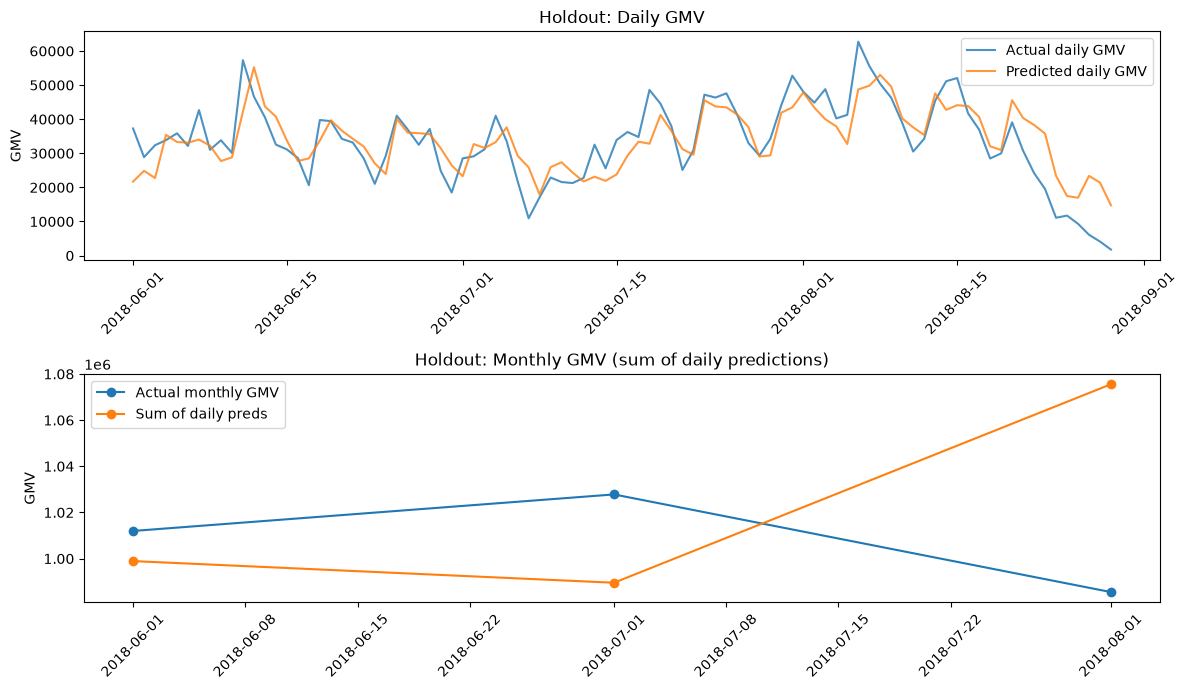

,order_date,gmv,predicted_gmv
596,2018-06-01,37282.67,21700.531913
597,2018-06-02,28870.67,24865.624949
598,2018-06-03,32375.80,22742.737750
599,2018-06-04,33866.17,35424.533785
600,2018-06-05,35864.93,33313.758133


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(test_eval["order_date"], test_eval["gmv"], label="Actual daily GMV", alpha=0.8)
axes[0].plot(test_eval["order_date"], test_eval["predicted_gmv"], label="Predicted daily GMV", alpha=0.8)
axes[0].set_title("Holdout: Daily GMV")
axes[0].set_ylabel("GMV")
axes[0].legend()

axes[1].plot(monthly_eval["month_start"], monthly_eval["gmv"], marker="o", label="Actual monthly GMV")
axes[1].plot(monthly_eval["month_start"], monthly_eval["predicted_gmv"], marker="o", label="Sum of daily preds")
axes[1].set_title("Holdout: Monthly GMV (sum of daily predictions)")
axes[1].set_ylabel("GMV")
axes[1].legend()
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

test_eval.head()

## 5) Feature Importance

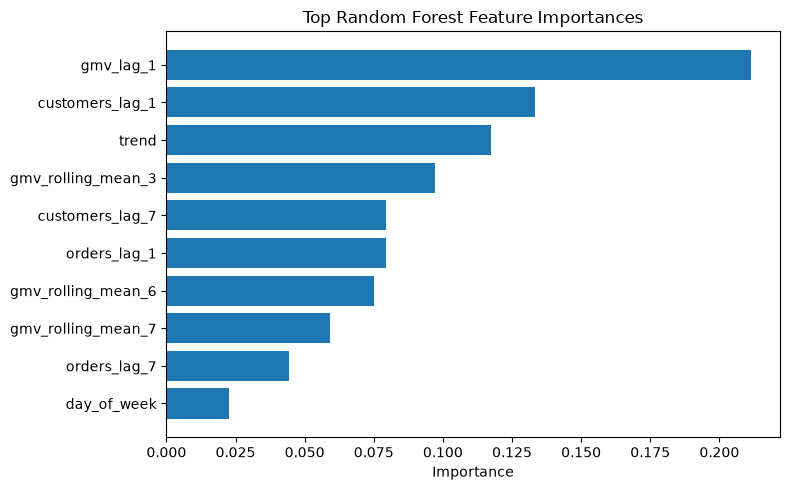

,forecast_run_id,generated_at,model,rank,feature,importance
0,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,1,gmv_lag_1,0.211352
1,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,2,customers_lag_1,0.133150
2,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,3,trend,0.117408
3,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,4,gmv_rolling_mean_3,0.097019
4,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,5,customers_lag_7,0.079396
5,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,6,orders_lag_1,0.079270
6,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,7,gmv_rolling_mean_6,0.075204
7,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,8,gmv_rolling_mean_7,0.059264
8,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,9,orders_lag_7,0.044438
9,0c21d1b07b1b4caaa91a34e3de2050dd,2026-08-25T01:44:59.508557+00:00,RandomForestRegressor,10,day_of_week,0.022736


In [8]:
feature_importance = build_feature_importance_table(
    rf_model,
    feature_cols,
    forecast_run_id=forecast_run_id,
    generated_at=generated_at,
)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"].head(10)[::-1], feature_importance["importance"].head(10)[::-1])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feature_importance

## 6) Recursive Forecast (next 30 days)

Call `recursive_forecast`: day 1 uses real history; later days use predicted GMV in lag features.

**Note:** `forecast_daily_unique_customers` is daily distinct customers. The monthly field `forecast_daily_unique_customers_sum` is the **sum of daily counts**, not calendar-month distinct customers (same buyer on multiple days is counted multiple times).

In [9]:
forecast_daily, forecast_monthly = recursive_forecast(
    df,
    rf_model,
    feature_cols,
    horizon_days=FORECAST_DAYS,
    forecast_run_id=forecast_run_id,
    generated_at=generated_at,
)

print(f"generated_at: {forecast_daily['generated_at'].iloc[0]}")

forecast_daily.head(), forecast_monthly

generated_at: 2026-08-25T01:44:59.508557+00:00


(                    forecast_run_id                      generated_at  order_date  forecast_step  forecast_gmv  forecast_orders  \
 0  0c21d1b07b1b4caaa91a34e3de2050dd  2026-08-25T01:44:59.508557+00:00  2018-08-30              1  12340.891342        75.910943   
 1  0c21d1b07b1b4caaa91a34e3de2050dd  2026-08-25T01:44:59.508557+00:00  2018-08-31              2  11555.554159        71.080199   
 2  0c21d1b07b1b4caaa91a34e3de2050dd  2026-08-25T01:44:59.508557+00:00  2018-09-01              3  12374.907417        76.120182   
 3  0c21d1b07b1b4caaa91a34e3de2050dd  2026-08-25T01:44:59.508557+00:00  2018-09-02              4  14200.277325        87.348346   
 4  0c21d1b07b1b4caaa91a34e3de2050dd  2026-08-25T01:44:59.508557+00:00  2018-09-03              5  15391.737145        94.677220   
 
    forecast_daily_unique_customers                  model  
 0                        75.633554  RandomForestRegressor  
 1                        70.820462  RandomForestRegressor  
 2                     

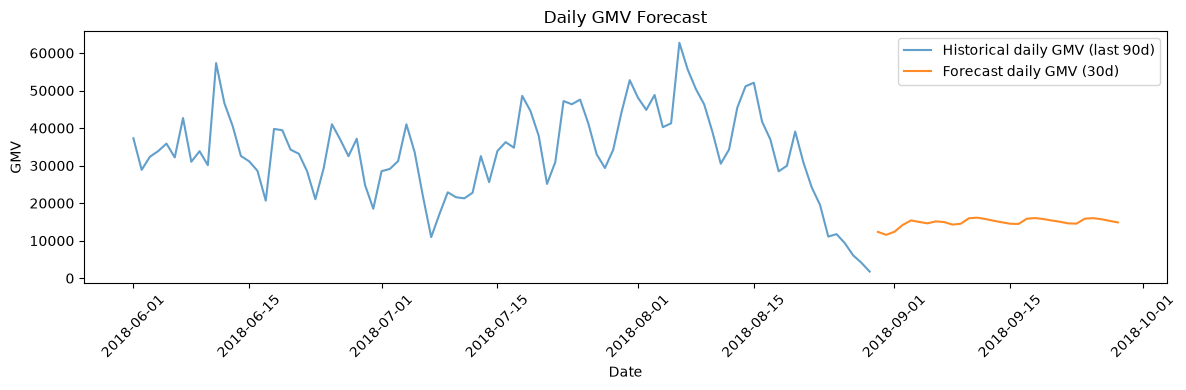

In [10]:
hist_tail = df.tail(90)
fc_dates = pd.to_datetime(forecast_daily["order_date"])

plt.figure(figsize=(12, 4))
plt.plot(hist_tail["order_date"], hist_tail["gmv"], label="Historical daily GMV (last 90d)", alpha=0.7)
plt.plot(fc_dates, forecast_daily["forecast_gmv"], label=f"Forecast daily GMV ({FORECAST_DAYS}d)", alpha=0.9)
plt.title("Daily GMV Forecast")
plt.xlabel("Date")
plt.ylabel("GMV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7) Export Results

In [11]:
forecast_daily.to_csv(FORECAST_DAILY_PATH, index=False)
forecast_monthly.to_csv(FORECAST_MONTHLY_PATH, index=False)
performance.to_csv(PERFORMANCE_PATH, index=False)
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

print(f"Wrote {INPUT_PATH}")
print(f"Wrote {FORECAST_DAILY_PATH}")
print(f"Wrote {FORECAST_MONTHLY_PATH}")
print(f"Wrote {PERFORMANCE_PATH}")
print(f"Wrote {FEATURE_IMPORTANCE_PATH}")

Wrote /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/processed/daily_business_metrics.csv
Wrote /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/output/forecast_result_daily.csv
Wrote /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/output/forecast_result_monthly.csv
Wrote /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/output/rf_model_performance.csv
Wrote /Users/sherrywang/Desktop/ecommerce-bi-dashboard/data/output/rf_feature_importance.csv
